# XGBoost Taxi Type Classification

Classify NYC taxi type (yellow vs green) in two settings: (Part A) raw trip-level data, (Part B) pivoted tables reduced to PC1–PC5 of the hourly profile.

## 1. Config

Path to raw parquet (directory or file), path to pivoted parquet (Part B), max rows per class for Part A (or None), random seed, train fraction.

---

In [1]:
PATH_RAW = "s3://dsc291-ucsd/taxi/Dataset/2023/"
PATH_PIVOTED = "data/input/taxi_wide_table.parquet"
MAX_ROWS_PER_CLASS = 50_000
RANDOM_SEED = 0
TRAIN_FRACTION = 0.8

## Part A: Classification from Raw Trip Data

## 2. Load and Prepare

Discover parquet files, normalize column names (e.g. Trip_Pickup_DateTime → tpep_pickup_datetime), load one file per taxi type with Dask, sample per class, compute to pandas. Derive trip_duration_min, hour, day_of_week. Features: trip_distance, trip_duration_min, hour, day_of_week, passenger_count. Drop rows with missing or invalid values.

In [2]:
from __future__ import annotations
from pathlib import Path
from typing import List
import fsspec


def is_s3_path(path: str | Path) -> bool:
    return str(path).startswith("s3://")


def get_filesystem(path: str | Path):
    if is_s3_path(path):
        return fsspec.filesystem("s3", anon=True)
    return fsspec.filesystem("file")


def discover_parquet_files(input_path: str | Path) -> List[str]:
    """Discover all .parquet files from directory or single file."""
    input_path = str(input_path)
    if input_path.endswith(".parquet"):
        return [input_path]
    fs = get_filesystem(input_path)
    if is_s3_path(input_path):
        stripped = input_path.replace("s3://", "", 1).rstrip("/")
        files = []
        for root, _, filenames in fs.walk(stripped):
            for name in filenames:
                if name.endswith(".parquet"):
                    files.append(f"s3://{root}/{name}")
    else:
        base = Path(input_path)
        if not base.exists():
            raise FileNotFoundError(f"Input path does not exist: {input_path}")
        files = [str(p) for p in base.rglob("*.parquet") if p.is_file()]
    files.sort()
    if not files:
        raise FileNotFoundError(f"No Parquet files found under {input_path}")
    return files


def infer_taxi_type_from_path(file_path: str | Path) -> str:
    """Infer taxi type (yellow, green, fhv, hvfhv) from file path."""
    path = str(file_path).lower()
    for taxi in ["yellow", "green", "fhv", "hvfhv"]:
        if taxi in path:
            return taxi
    return "unknown"


def find_pickup_datetime_col(columns: List[str]) -> str | None:
    candidates = ["Trip_Pickup_DateTime", "lpep_pickup_datetime", "pickup_datetime", "tpep_pickup_datetime"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def find_dropoff_datetime_col(columns: List[str]) -> str | None:
    candidates = ["Trip_Dropoff_DateTime", "lpep_dropoff_datetime", "dropoff_datetime", "dropOff_datetime", "tpep_dropoff_datetime"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def find_dist_col(columns: List[str]) -> str | None:
    candidates = ["trip_distance", "Trip_Distance", "trip_miles", "Trip_Miles"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def find_passenger_count_col(columns: List[str]) -> str | None:
    candidates = ["passenger_count", "Passenger_Count"]
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def normalize_columns(df_columns: List[str]) -> dict:
    """Build rename dict to normalize schema to tpep_* / trip_distance / passenger_count."""
    renames = {}
    pickup = find_pickup_datetime_col(df_columns)
    if pickup:
        renames[pickup] = "tpep_pickup_datetime"
    dropoff = find_dropoff_datetime_col(df_columns)
    if dropoff:
        renames[dropoff] = "tpep_dropoff_datetime"
    dist = find_dist_col(df_columns)
    if dist and dist != "trip_distance":
        renames[dist] = "trip_distance"
    pax = find_passenger_count_col(df_columns)
    if pax and pax != "passenger_count":
        renames[pax] = "passenger_count"
    return renames

In [3]:
import dask.dataframe as dd
import pandas as pd
import numpy as np

# Discover files and group by taxi type
all_files = discover_parquet_files(PATH_RAW)
by_type = {}
for f in all_files:
    t = infer_taxi_type_from_path(f)
    if t not in by_type:
        by_type[t] = []
    by_type[t].append(f)

# Keep only yellow and green; pick one file per type
wanted = {k: v[0] for k, v in by_type.items() if k in ("yellow", "green")}
if "yellow" not in wanted or "green" not in wanted:
    raise ValueError(f"Need both yellow and green parquet files. Found: {list(by_type.keys())}")

storage_options = {"anon": True} if str(PATH_RAW).startswith("s3://") else {}
parts = []
for taxi_type, path in wanted.items():
    ddf = dd.read_parquet(path, engine="pyarrow", storage_options=storage_options)
    cols = list(ddf.columns)
    renames = normalize_columns(cols)
    if renames:
        ddf = ddf.rename(columns=renames)
    ddf = ddf.assign(taxi_type=taxi_type)
    parts.append(ddf)

combined_ddf = dd.concat(parts, axis=0, ignore_index=True)
raw_df = combined_ddf.compute()

# Sample per class in pandas (avoids Dask length computation)
if MAX_ROWS_PER_CLASS is not None:
    sampled = []
    for tt in wanted.keys():
        sub = raw_df.loc[raw_df["taxi_type"] == tt]
        if len(sub) > MAX_ROWS_PER_CLASS:
            sub = sub.sample(n=MAX_ROWS_PER_CLASS, random_state=RANDOM_SEED, replace=False)
        sampled.append(sub)
    raw_df = pd.concat(sampled, ignore_index=True)
print(f"Loaded {len(raw_df)} rows from {list(wanted.keys())}")

Loaded 100000 rows from ['green', 'yellow']


In [4]:
# Derive features and clean
df = raw_df.copy()
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")
df["trip_duration_min"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek

# Drop missing
df = df.dropna(subset=["trip_distance", "trip_duration_min", "passenger_count", "hour", "day_of_week"])

# Drop invalid (non-positive distance/duration)
df = df.loc[(df["trip_distance"] > 0) & (df["trip_duration_min"] > 0)]

# Select features and target
FEATURE_COLS = ["trip_distance", "trip_duration_min", "hour", "day_of_week", "passenger_count"]
X = df[FEATURE_COLS].copy()
print(f"Cleaned: {len(X)} rows. Class counts:\n{df['taxi_type'].value_counts()}")

Cleaned: 92711 rows. Class counts:
taxi_type
yellow    48205
green     44506
Name: count, dtype: int64


## 3. Train and Evaluate

Stratified train/validation split, fit XGBClassifier (multi-class: objective="multi:softmax"), report classification report and accuracy.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(df["taxi_type"])
class_names = le.classes_.tolist()
num_class = len(class_names)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, train_size=TRAIN_FRACTION, stratify=y_enc, random_state=RANDOM_SEED
)

model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=num_class,
    random_state=RANDOM_SEED,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred, target_names=class_names))
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")

              precision    recall  f1-score   support

       green       0.61      0.65      0.63      8902
      yellow       0.65      0.62      0.63      9641

    accuracy                           0.63     18543
   macro avg       0.63      0.63      0.63     18543
weighted avg       0.63      0.63      0.63     18543

Accuracy: 0.6308


## 4. Interpret

One figure with three panels: (1) confusion matrix, (2) feature importance (horizontal bar chart), (3) value range (boxplot) of features for one class (e.g. yellow).

C:\Users\TangyKiwi\AppData\Local\Temp\ipykernel_11620\2475245222.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot([subset[c].values for c in FEATURE_COLS], labels=FEATURE_COLS, patch_artist=True)


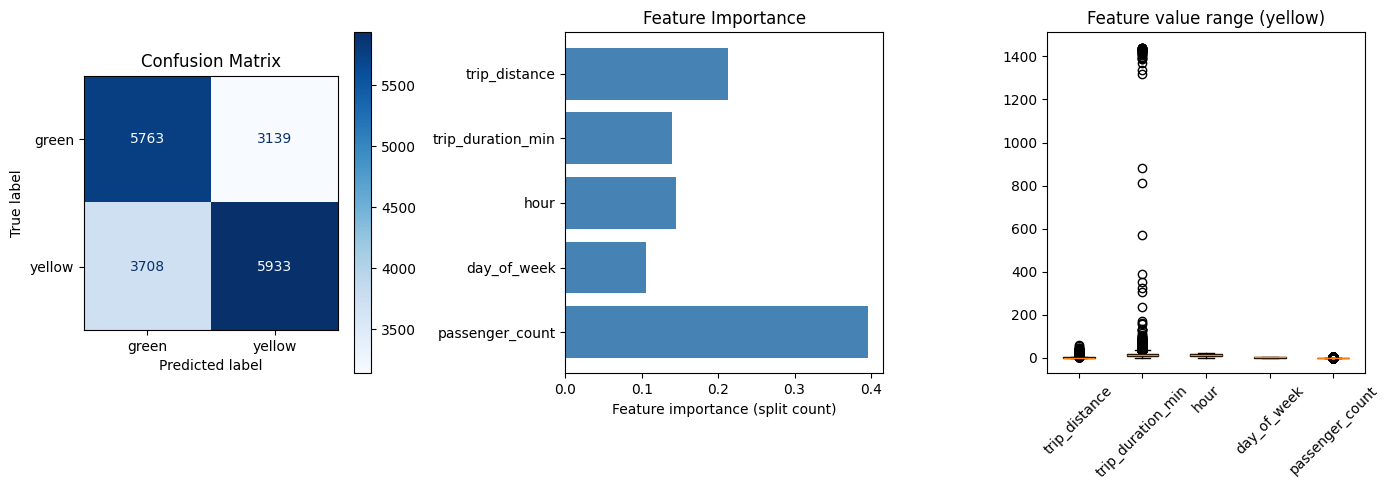

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# (1) Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")

# (2) Feature importance (split count)
imps = model.feature_importances_
axes[1].barh(FEATURE_COLS, imps, color="steelblue")
axes[1].set_xlabel("Feature importance (split count)")
axes[1].set_title("Feature Importance")
axes[1].invert_yaxis()

# (3) Boxplot of features for one class (e.g. yellow)
sample_class = "yellow"
subset = df.loc[df["taxi_type"] == sample_class][FEATURE_COLS]
bp = axes[2].boxplot([subset[c].values for c in FEATURE_COLS], labels=FEATURE_COLS, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
axes[2].set_title(f"Feature value range ({sample_class})")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## Part B: Classification from Pivoted Tables

Read pivoted parquet (rows = date, taxi_type, pickup_place; columns = hour_0...hour_23). Convert hourly counts to proportions, fit PCA, use PC1–PC5 as features.

### Part B.1 Load

Read pivoted parquet with Dask; keep rows with valid taxi_type and hour_0...hour_23; restrict to yellow and green.

In [7]:
hour_cols = [f"hour_{i}" for i in range(24)]
ddf_b = dd.read_parquet(PATH_PIVOTED, engine="pyarrow")
df_b = ddf_b.compute()
df_b = df_b.dropna(subset=["taxi_type"] + hour_cols)
df_b = df_b.loc[df_b["taxi_type"].str.lower().isin(["yellow", "green"])]
df_b = df_b.reset_index(drop=True)
print(f"Part B loaded: {len(df_b)} rows. Class counts:\n{df_b['taxi_type'].value_counts()}")

Part B loaded: 655584 rows. Class counts:
taxi_type
yellow    470117
green     185467
Name: count, dtype: int64[pyarrow]


### Part B.2 Features

Convert hourly counts to row proportions; fit PCA (5 components) on the 24-dimensional profile; use PC1–PC5 as features.

In [8]:
from sklearn.decomposition import PCA

# Row proportions (each row sums to 1)
H = df_b[hour_cols].values.astype(float)
row_sums = H.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
H_prop = H / row_sums

# Fit PCA and transform
n_components = 5
pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
X_b = pca.fit_transform(H_prop)
PC_COLS = [f"PC{i+1}" for i in range(n_components)]
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

PCA explained variance ratio: [0.3525966  0.15960926 0.12874766 0.04772951 0.0360049 ]


### Part B.3 Train and Evaluate

Encode taxi_type (LabelEncoder); stratified split; fit XGBClassifier; report classification report and accuracy.

In [9]:
le_b = LabelEncoder()
y_b = le_b.fit_transform(df_b["taxi_type"])
class_names_b = le_b.classes_.tolist()
num_class_b = len(class_names_b)

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_b, y_b, train_size=TRAIN_FRACTION, stratify=y_b, random_state=RANDOM_SEED
)

model_b = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=num_class_b,
    random_state=RANDOM_SEED,
)
model_b.fit(X_train_b, y_train_b)

y_pred_b = model_b.predict(X_val_b)
print(classification_report(y_val_b, y_pred_b, target_names=class_names_b))
print(f"Accuracy: {accuracy_score(y_val_b, y_pred_b):.4f}")

              precision    recall  f1-score   support

       green       0.71      0.52      0.60     37093
      yellow       0.83      0.92      0.87     94024

    accuracy                           0.80    131117
   macro avg       0.77      0.72      0.74    131117
weighted avg       0.80      0.80      0.79    131117

Accuracy: 0.8047


### Part B.4 Interpret

Plot confusion matrix and feature importance (which PCs matter most).

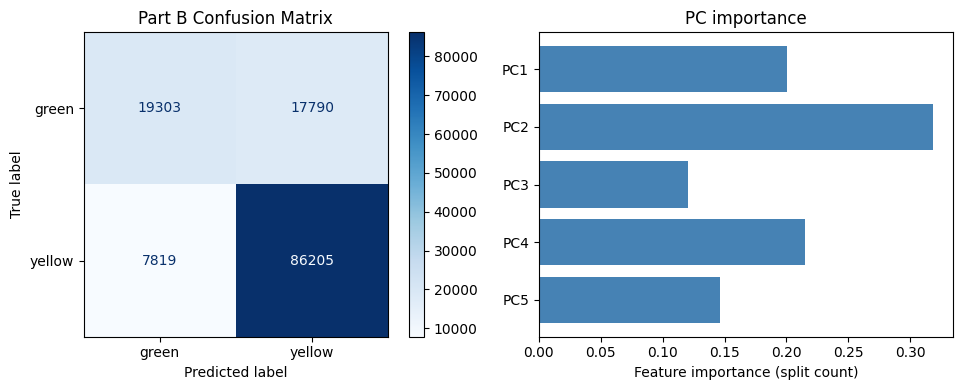

In [10]:
fig_b, axes_b = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix
cm_b = confusion_matrix(y_val_b, y_pred_b)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=class_names_b)
disp_b.plot(ax=axes_b[0], cmap="Blues")
axes_b[0].set_title("Part B Confusion Matrix")

# Feature importance (PCs)
imps_b = model_b.feature_importances_
axes_b[1].barh(PC_COLS, imps_b, color="steelblue")
axes_b[1].set_xlabel("Feature importance (split count)")
axes_b[1].set_title("PC importance")
axes_b[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Extra Credit: Bootstrap Stability & Prediction Confidence

In [11]:

from sklearn.metrics import accuracy_score, f1_score
from collections import defaultdict

BOOTSTRAP_ITERS = 25
PARAM_GRID_SAMPLE_SIZE = None


def make_xgb_classifier(num_class: int, random_state: int = 0, **kwargs):
    """
    Build an XGBClassifier that supports predict_proba.
    Binary -> binary:logistic
    Multiclass -> multi:softprob
    """
    base = dict(
        random_state=random_state,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.10,
        subsample=0.90,
        colsample_bytree=0.90,
        min_child_weight=1,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="logloss",
    )
    base.update(kwargs)

    if num_class <= 2:
        return xgb.XGBClassifier(objective="binary:logistic", **base)
    return xgb.XGBClassifier(objective="multi:softprob", num_class=num_class, **base)


def bootstrap_xgb_stability(
    X_train,
    y_train,
    X_val,
    y_val,
    feature_names,
    class_names,
    n_boot=25,
    seed=0,
    model_kwargs=None,
):
    """
    Refit the model on bootstrap samples of the training set.
    Returns metric distributions, importance stability, and predictive uncertainty.
    """
    model_kwargs = {} if model_kwargs is None else dict(model_kwargs)
    rng = np.random.default_rng(seed)

    X_train_np = np.asarray(X_train)
    y_train_np = np.asarray(y_train)
    X_val_np = np.asarray(X_val)
    y_val_np = np.asarray(y_val)

    metrics = []
    importances = []
    probas = []

    n_train = len(X_train_np)
    num_class = len(class_names)

    for b in range(n_boot):
        idx = rng.integers(0, n_train, size=n_train)
        model_boot = make_xgb_classifier(
            num_class=num_class,
            random_state=seed + b,
            **model_kwargs,
        )
        model_boot.fit(X_train_np[idx], y_train_np[idx])

        y_pred_boot = model_boot.predict(X_val_np)
        y_prob_boot = model_boot.predict_proba(X_val_np)

        metrics.append({
            "bootstrap_iter": b,
            "accuracy": accuracy_score(y_val_np, y_pred_boot),
            "f1_macro": f1_score(y_val_np, y_pred_boot, average="macro"),
            "f1_weighted": f1_score(y_val_np, y_pred_boot, average="weighted"),
        })
        importances.append(model_boot.feature_importances_)
        probas.append(y_prob_boot)

    metrics_df = pd.DataFrame(metrics)
    importances_arr = np.vstack(importances)
    probas_arr = np.stack(probas, axis=0)  # (boot, n_samples, n_classes)

    importance_summary = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": importances_arr.mean(axis=0),
        "importance_std": importances_arr.std(axis=0),
        "importance_cv": importances_arr.std(axis=0) / np.clip(importances_arr.mean(axis=0), 1e-9, None),
    }).sort_values("importance_mean", ascending=False)

    pred_class_idx = probas_arr.mean(axis=0).argmax(axis=1)
    pred_class_name = [class_names[i] for i in pred_class_idx]
    pred_prob_mean = probas_arr.mean(axis=0).max(axis=1)
    pred_prob_std = np.take_along_axis(probas_arr.std(axis=0), pred_class_idx[:, None], axis=1).ravel()
    pred_prob_lo = np.take_along_axis(np.quantile(probas_arr, 0.025, axis=0), pred_class_idx[:, None], axis=1).ravel()
    pred_prob_hi = np.take_along_axis(np.quantile(probas_arr, 0.975, axis=0), pred_class_idx[:, None], axis=1).ravel()

    prediction_confidence = pd.DataFrame({
        "true_class": [class_names[i] for i in y_val_np],
        "predicted_class": pred_class_name,
        "pred_prob_mean": pred_prob_mean,
        "pred_prob_std": pred_prob_std,
        "pred_prob_ci_low": pred_prob_lo,
        "pred_prob_ci_high": pred_prob_hi,
    })

    summary = {
        "accuracy_mean": metrics_df["accuracy"].mean(),
        "accuracy_std": metrics_df["accuracy"].std(),
        "accuracy_ci_low": metrics_df["accuracy"].quantile(0.025),
        "accuracy_ci_high": metrics_df["accuracy"].quantile(0.975),
        "f1_macro_mean": metrics_df["f1_macro"].mean(),
        "f1_macro_std": metrics_df["f1_macro"].std(),
        "f1_macro_ci_low": metrics_df["f1_macro"].quantile(0.025),
        "f1_macro_ci_high": metrics_df["f1_macro"].quantile(0.975),
    }

    return {
        "metrics": metrics_df,
        "importance_summary": importance_summary,
        "prediction_confidence": prediction_confidence,
        "summary": summary,
    }


def plot_bootstrap_results(title_prefix, boot_result, top_n=8):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Metrics distribution
    axes[0].hist(boot_result["metrics"]["f1_macro"], bins=12)
    axes[0].axvline(boot_result["summary"]["f1_macro_mean"], linestyle="--")
    axes[0].set_title(f"{title_prefix}: Bootstrap Macro-F1")
    axes[0].set_xlabel("Macro-F1")
    axes[0].set_ylabel("Count")

    # Importance stability
    imp = boot_result["importance_summary"].head(top_n).sort_values("importance_mean")
    axes[1].barh(imp["feature"], imp["importance_mean"], xerr=imp["importance_std"])
    axes[1].set_title(f"{title_prefix}: Importance Stability")
    axes[1].set_xlabel("Mean importance ± 1 SD")

    # Prediction confidence
    conf = boot_result["prediction_confidence"].copy()
    conf["is_correct"] = conf["true_class"] == conf["predicted_class"]
    axes[2].boxplot(
        [
            conf.loc[conf["is_correct"], "pred_prob_mean"],
            conf.loc[~conf["is_correct"], "pred_prob_mean"],
        ],
        labels=["Correct", "Incorrect"],
    )
    axes[2].set_title(f"{title_prefix}: Validation Confidence")
    axes[2].set_ylabel("Bootstrap mean predicted probability")

    plt.tight_layout()
    plt.show()

Part A bootstrap summary:
accuracy_mean: 0.6295
accuracy_std: 0.0020
accuracy_ci_low: 0.6263
accuracy_ci_high: 0.6333
f1_macro_mean: 0.6295
f1_macro_std: 0.0020
f1_macro_ci_low: 0.6261
f1_macro_ci_high: 0.6332


,feature,importance_mean,importance_std,importance_cv
4,passenger_count,0.388541,0.015189,0.039091
0,trip_distance,0.230541,0.010318,0.044754
2,hour,0.155788,0.006059,0.038894
1,trip_duration_min,0.128245,0.005598,0.043650
3,day_of_week,0.096884,0.005069,0.052321


,true_class,predicted_class,pred_prob_mean,pred_prob_std,pred_prob_ci_low,pred_prob_ci_high
0,green,yellow,0.574464,0.035109,0.515197,0.635394
1,green,green,0.715480,0.026810,0.679353,0.772185
2,yellow,green,0.504548,0.033443,0.450754,0.565015
3,yellow,green,0.690751,0.133364,0.402111,0.864960
4,green,green,0.609704,0.017419,0.577886,0.640385
5,yellow,green,0.601723,0.024667,0.550439,0.635547
6,green,green,0.503297,0.026827,0.456667,0.552141
7,green,green,0.523071,0.015998,0.494800,0.555436
8,green,yellow,0.526160,0.030331,0.471709,0.572406
9,yellow,yellow,0.677055,0.029903,0.634967,0.743128


C:\Users\TangyKiwi\AppData\Local\Temp\ipykernel_11620\2618400449.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


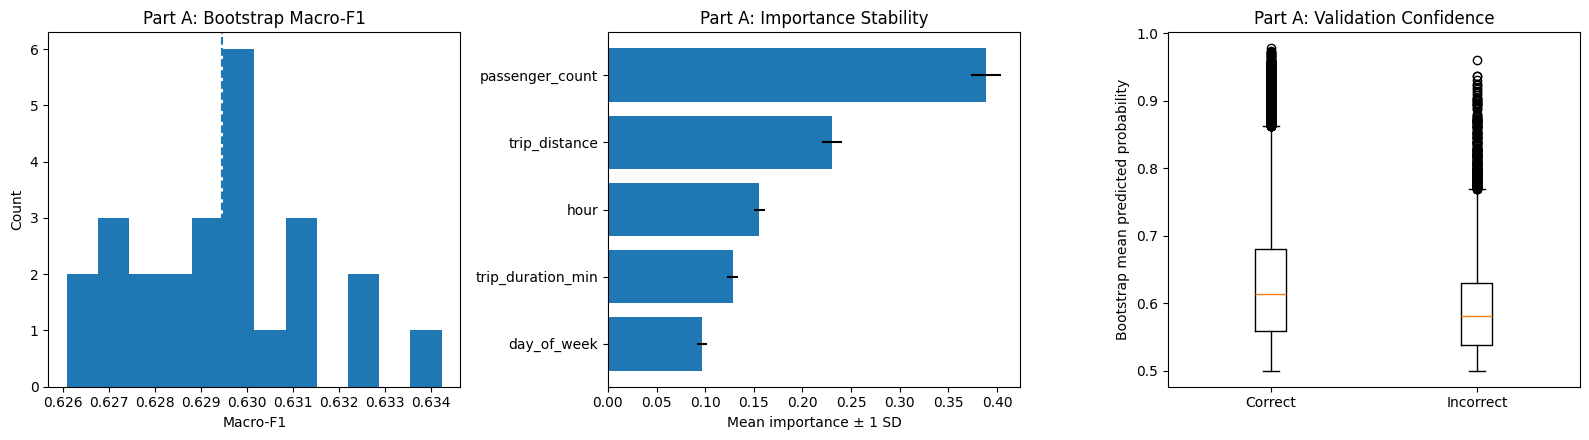

In [12]:
part_a_boot = bootstrap_xgb_stability(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    feature_names=FEATURE_COLS,
    class_names=class_names,
    n_boot=BOOTSTRAP_ITERS,
    seed=RANDOM_SEED,
)

print("Part A bootstrap summary:")
for k, v in part_a_boot["summary"].items():
    print(f"{k}: {v:.4f}")

display(part_a_boot["importance_summary"])
display(part_a_boot["prediction_confidence"].head(10))

plot_bootstrap_results("Part A", part_a_boot)

Part B bootstrap summary:
accuracy_mean: 0.7932
accuracy_std: 0.0005
accuracy_ci_low: 0.7926
accuracy_ci_high: 0.7942
f1_macro_mean: 0.7101
f1_macro_std: 0.0007
f1_macro_ci_low: 0.7090
f1_macro_ci_high: 0.7113


,feature,importance_mean,importance_std,importance_cv
1,PC2,0.303382,0.017839,0.058800
3,PC4,0.232714,0.010056,0.043213
0,PC1,0.193997,0.009797,0.050503
4,PC5,0.153010,0.005700,0.037251
2,PC3,0.116898,0.006359,0.054400


,true_class,predicted_class,pred_prob_mean,pred_prob_std,pred_prob_ci_low,pred_prob_ci_high
0,green,yellow,0.643227,0.021927,0.597702,0.677186
1,yellow,yellow,0.805663,0.012821,0.784519,0.825436
2,yellow,yellow,0.876047,0.010909,0.858733,0.895413
3,yellow,green,0.616531,0.021939,0.581395,0.657230
4,yellow,yellow,0.817956,0.022059,0.771381,0.850165
5,yellow,yellow,0.896382,0.008075,0.880861,0.906635
6,green,yellow,0.796604,0.019846,0.748978,0.823349
7,yellow,yellow,0.605188,0.031073,0.545724,0.666025
8,yellow,yellow,0.863462,0.013090,0.847584,0.887097
9,green,green,0.795413,0.015809,0.767614,0.828812


C:\Users\TangyKiwi\AppData\Local\Temp\ipykernel_11620\2618400449.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


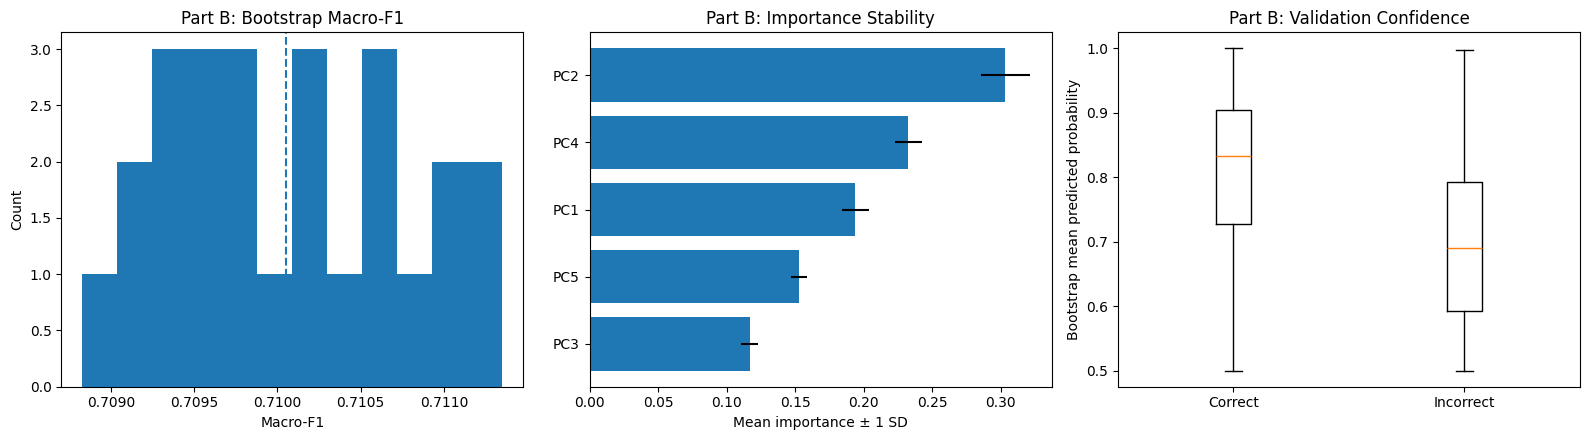

In [13]:
part_b_boot = bootstrap_xgb_stability(
    X_train=X_train_b,
    y_train=y_train_b,
    X_val=X_val_b,
    y_val=y_val_b,
    feature_names=PC_COLS,
    class_names=class_names_b,
    n_boot=BOOTSTRAP_ITERS,
    seed=RANDOM_SEED,
)

print("Part B bootstrap summary:")
for k, v in part_b_boot["summary"].items():
    print(f"{k}: {v:.4f}")

display(part_b_boot["importance_summary"])
display(part_b_boot["prediction_confidence"].head(10))

plot_bootstrap_results("Part B", part_b_boot)

### Extra Credit: XGBoost Parameter Study

In [14]:
from itertools import product

PARAM_GRID = {
    "max_depth": [2, 4, 6, 8],
    "learning_rate": [0.03, 0.10, 0.30],
    "n_estimators": [100, 200, 400],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "min_child_weight": [1, 5],
}


def maybe_subsample_train(X_train, y_train, n=None, seed=0):
    if n is None or len(X_train) <= n:
        return np.asarray(X_train), np.asarray(y_train)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X_train), size=n, replace=False)
    return np.asarray(X_train)[idx], np.asarray(y_train)[idx]


def parameter_sensitivity_study(
    X_train,
    y_train,
    X_val,
    y_val,
    class_names,
    param_grid,
    seed=0,
    train_sample_size=None,
):
    X_train_use, y_train_use = maybe_subsample_train(X_train, y_train, n=train_sample_size, seed=seed)
    X_val_np = np.asarray(X_val)
    y_val_np = np.asarray(y_val)
    num_class = len(class_names)

    keys = list(param_grid.keys())
    rows = []

    for values in product(*[param_grid[k] for k in keys]):
        params = dict(zip(keys, values))
        model_grid = make_xgb_classifier(num_class=num_class, random_state=seed, **params)
        model_grid.fit(X_train_use, y_train_use)
        y_pred_grid = model_grid.predict(X_val_np)
        rows.append({
            **params,
            "accuracy": accuracy_score(y_val_np, y_pred_grid),
            "f1_macro": f1_score(y_val_np, y_pred_grid, average="macro"),
            "f1_weighted": f1_score(y_val_np, y_pred_grid, average="weighted"),
        })

    results = pd.DataFrame(rows).sort_values(["f1_macro", "accuracy"], ascending=False).reset_index(drop=True)
    return results


def plot_parameter_dependence(results_df, title_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()

    params_to_plot = [
        "max_depth",
        "learning_rate",
        "n_estimators",
        "subsample",
        "colsample_bytree",
        "min_child_weight",
    ]

    for ax, param in zip(axes, params_to_plot):
        grouped = results_df.groupby(param, as_index=False)["f1_macro"].agg(["mean", "std"]).reset_index()
        ax.errorbar(grouped[param], grouped["mean"], yerr=grouped["std"], marker="o")
        ax.set_title(f"{title_prefix}: {param}")
        ax.set_xlabel(param)
        ax.set_ylabel("Macro-F1")

    plt.tight_layout()
    plt.show()

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,min_child_weight,accuracy,f1_macro,f1_weighted
0,4,0.30,200,1.0,1.0,5,0.637060,0.637002,0.637184
1,4,0.30,200,1.0,1.0,1,0.636844,0.636780,0.636972
2,4,0.30,100,1.0,1.0,1,0.636413,0.636375,0.636523
3,4,0.30,100,1.0,1.0,5,0.636359,0.636331,0.636458
4,4,0.10,400,1.0,1.0,1,0.636305,0.636260,0.636421
5,4,0.10,400,1.0,0.7,5,0.636089,0.636047,0.636203
6,6,0.03,400,1.0,1.0,1,0.636035,0.636000,0.636142
7,4,0.10,400,1.0,1.0,5,0.635981,0.635920,0.636108
8,4,0.30,100,0.7,1.0,5,0.635658,0.635622,0.635765
9,4,0.30,100,0.7,1.0,1,0.635496,0.635465,0.635598


Best Part A configuration:


,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,min_child_weight,accuracy,f1_macro,f1_weighted
0,4,0.3,200,1.0,1.0,5,0.63706,0.637002,0.637184


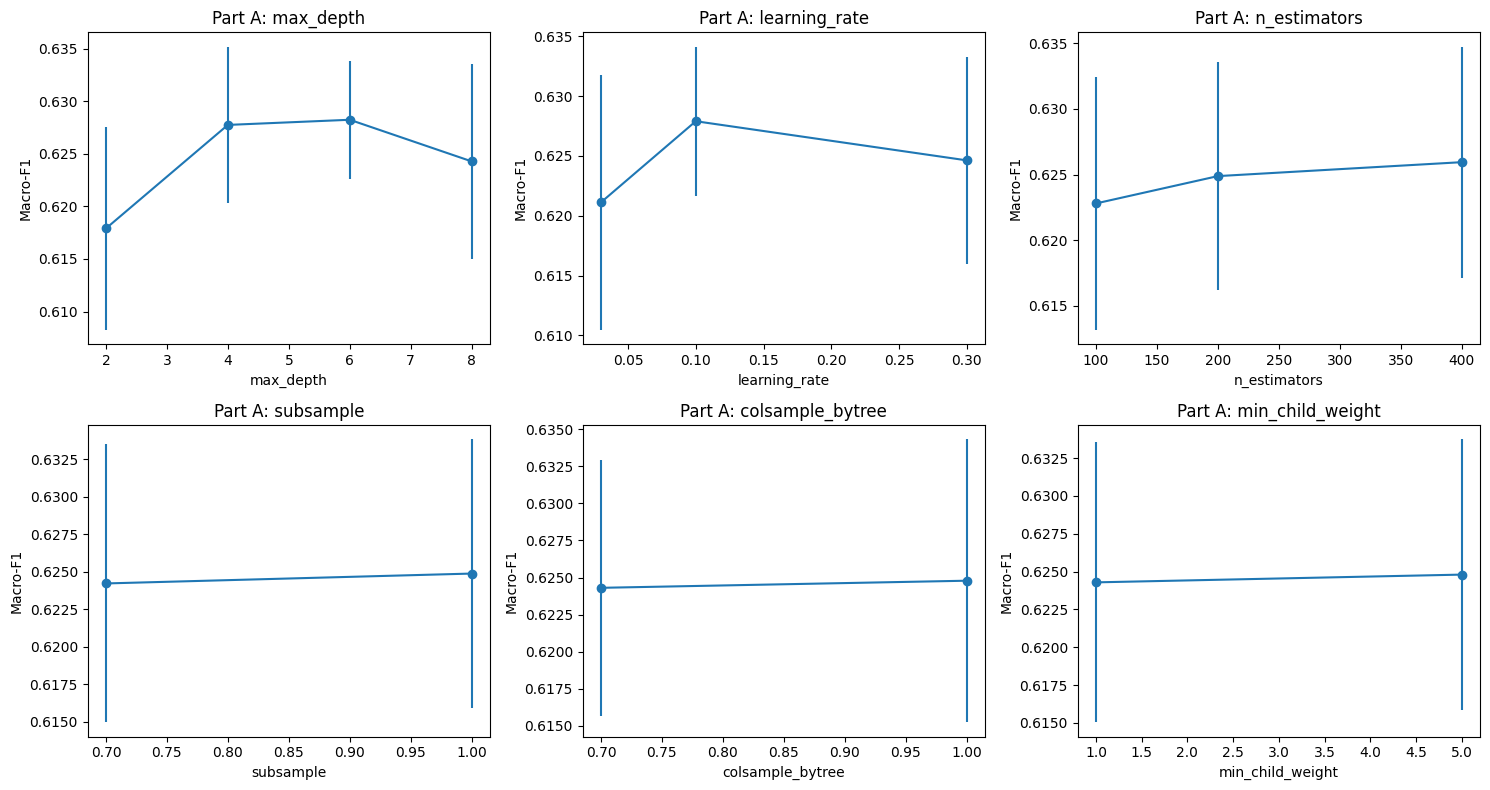

In [15]:
param_results_a = parameter_sensitivity_study(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    class_names=class_names,
    param_grid=PARAM_GRID,
    seed=RANDOM_SEED,
    train_sample_size=PARAM_GRID_SAMPLE_SIZE,
)

display(param_results_a.head(15))
print("Best Part A configuration:")
display(param_results_a.head(1))

plot_parameter_dependence(param_results_a, "Part A")

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,min_child_weight,accuracy,f1_macro,f1_weighted
0,8,0.03,400,0.7,1.0,1,0.791362,0.717997,0.780451
1,8,0.03,400,0.7,1.0,5,0.791453,0.717280,0.780157
2,8,0.10,100,0.7,1.0,1,0.789669,0.716013,0.778810
3,8,0.03,200,0.7,1.0,1,0.792933,0.715609,0.779997
4,8,0.10,100,0.7,1.0,5,0.789432,0.714737,0.778118
5,8,0.03,200,0.7,1.0,5,0.792559,0.714455,0.779298
6,8,0.10,200,0.7,1.0,5,0.786572,0.714098,0.776599
7,6,0.03,400,0.7,1.0,5,0.791316,0.713999,0.778566
8,6,0.03,400,0.7,1.0,1,0.791171,0.713959,0.778487
9,8,0.03,400,1.0,1.0,5,0.789608,0.713469,0.777602


Best Part B configuration:


,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,min_child_weight,accuracy,f1_macro,f1_weighted
0,8,0.03,400,0.7,1.0,1,0.791362,0.717997,0.780451


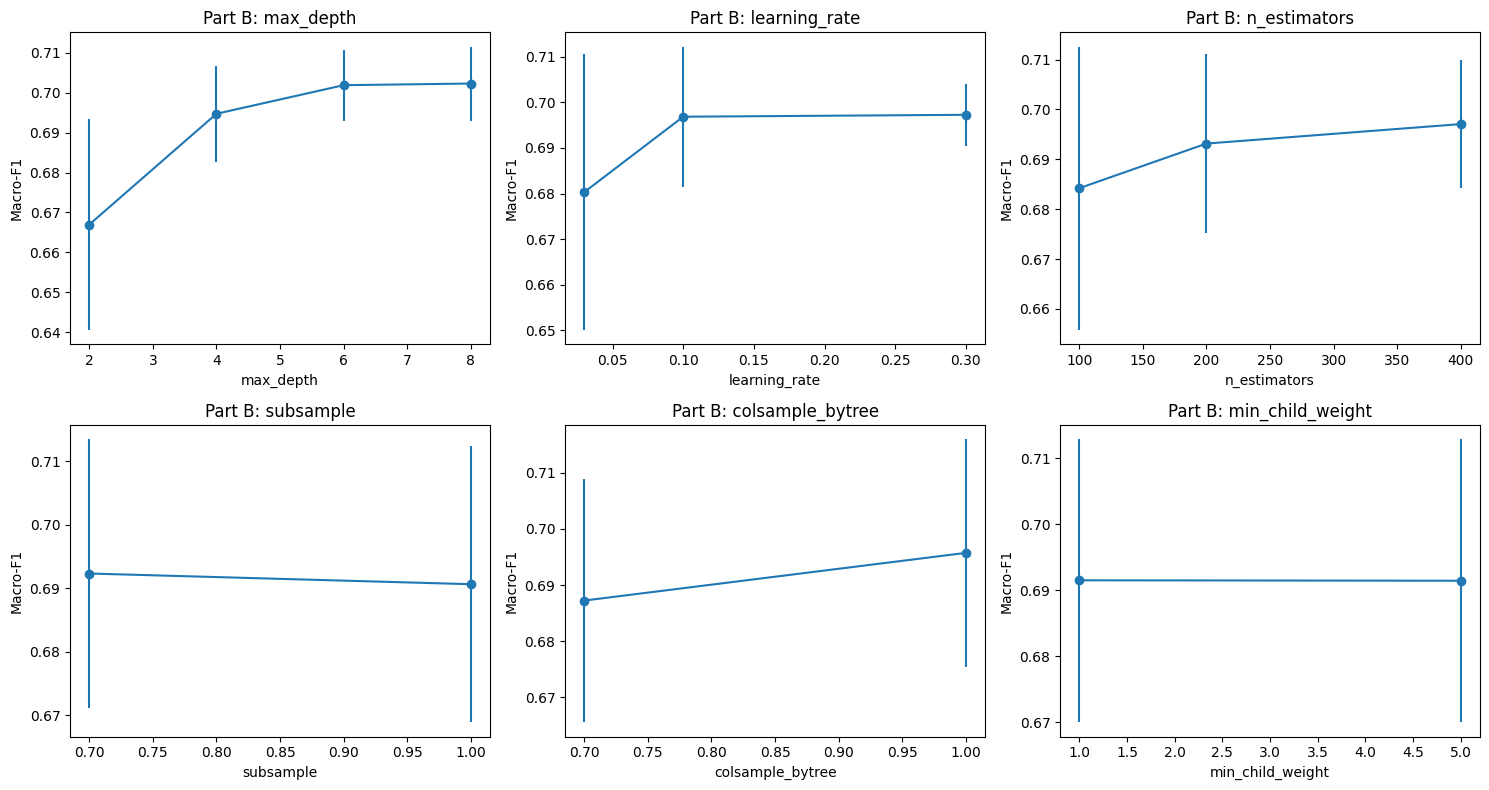

In [17]:
param_results_b = parameter_sensitivity_study(
    X_train=X_train_b,
    y_train=y_train_b,
    X_val=X_val_b,
    y_val=y_val_b,
    class_names=class_names_b,
    param_grid=PARAM_GRID,
    seed=RANDOM_SEED,
    train_sample_size=10000,
)

display(param_results_b.head(15))
print("Best Part B configuration:")
display(param_results_b.head(1))

plot_parameter_dependence(param_results_b, "Part B")